# 02 — Modelling: baseline, SARIMA, Prophet, LSTM under one CV

> **This data is synthetic** (generated by `src/generate_data.py`). Not real.

This notebook compares four forecasters on **identical** rolling-origin folds and scores them with **MASE** against the seasonal-naive baseline. The metric and the CV harness live in `src/evaluation.py`; the models share one fit/predict interface in `src/models.py`.

### Part A (this checkpoint) — harness + baseline
1. Build the **one shared CV configuration** every model will reuse.
2. Implement MASE scaled against the **in-sample, training-only** seasonal-naive error.
3. Run the seasonal-naive baseline through the harness.
4. **Two correctness gates** before any other model is allowed in:
   - **Sanity check** — seasonal-naive scored with this MASE must come out ≈ 1.0.
   - **Cross-check** — the hand-rolled MASE must match `utilsforecast.losses.mase`.

### Leakage discipline (carried from the EDA stage)
- Target input: **lagged `sales` only**.
- Exogenous input: the event **flags** `is_match_day`, `is_bank_holiday` only — both known months ahead, so legitimate known-future regressors.
- The generator's ground-truth columns (`baseline/trend/weekly/annual/events/mu`) are **never** features.
- **No random splits anywhere.** Time-ordered, expanding-window folds only.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_SEED, set_seeds
from src.evaluation import (
    CVConfig, rolling_origin_cv, summarize, mase, mae, seasonal_naive_scale,
)
from src.models import SeasonalNaive

set_seeds(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
print(f"seed={RANDOM_SEED}  results={RESULTS.relative_to(ROOT)}")


seed=42  results=results


## 1 · Load the series and the known-future event flags

In [2]:
df = pd.read_csv(ROOT / "data" / "sales.csv", comment="#", parse_dates=["date"])
df = df.set_index("date").asfreq("D")
assert df.index.freq is not None and df["sales"].isna().sum() == 0

y = df["sales"]
# Exogenous regressors = the two binary event flags ONLY (known-future).
# match_importance is available but we restrict to the flags named in the brief.
X = df[["is_match_day", "is_bank_holiday"]].astype(float)

print(f"y: {len(y):,} daily obs, {y.index.min().date()} -> {y.index.max().date()}")
print(f"X: exogenous flags = {list(X.columns)}")
X.sum().rename("active days").to_frame().T


y: 1,096 daily obs, 2022-01-01 -> 2024-12-31
X: exogenous flags = ['is_match_day', 'is_bank_holiday']


,is_match_day,is_bank_holiday
active days,326.0,30.0


## 2 · The one shared CV configuration

Every model is scored on **these exact folds** — same cutoffs, same test weeks, same per-fold scale. If the splits differed between models the comparison would be meaningless.

- **Horizon h = 7** — one week ahead, matching the ordering/rostering decision.
- **Step = 7** — weekly origins, non-overlapping test blocks.
- **26 origins** — expanding window; the first fold already has ~2.5 years of training, enough for SARIMA to estimate the weekly + annual structure.


In [3]:
cv = CVConfig(horizon=7, step_size=7, n_origins=26, m=7)
folds = cv.describe(y.index)
print(f"{len(folds)} expanding-window folds")
print(f"first fold trains on {folds.iloc[0]['n_train']} days "
      f"(-> {folds.iloc[0]['train_end']}), tests {folds.iloc[0]['test_start']}..{folds.iloc[0]['test_end']}")
print(f"last  fold trains on {folds.iloc[-1]['n_train']} days "
      f"(-> {folds.iloc[-1]['train_end']}), tests {folds.iloc[-1]['test_start']}..{folds.iloc[-1]['test_end']}")
pd.concat([folds.head(3), folds.tail(3)])


26 expanding-window folds
first fold trains on 914 days (-> 2024-07-02), tests 2024-07-03..2024-07-09
last  fold trains on 1089 days (-> 2024-12-24), tests 2024-12-25..2024-12-31


,fold,n_train,train_start,train_end,test_start,test_end
0,0,914,2022-01-01,2024-07-02,2024-07-03,2024-07-09
1,1,921,2022-01-01,2024-07-09,2024-07-10,2024-07-16
2,2,928,2022-01-01,2024-07-16,2024-07-17,2024-07-23
23,23,1075,2022-01-01,2024-12-10,2024-12-11,2024-12-17
24,24,1082,2022-01-01,2024-12-17,2024-12-18,2024-12-24
25,25,1089,2022-01-01,2024-12-24,2024-12-25,2024-12-31


## 3 · MASE — scaled against the in-sample, training-only seasonal naive

For a fold with training series $y^{tr}$ (length $n$) and test actuals/forecasts over the horizon:

$$\text{MASE} = \frac{\frac{1}{h}\sum_{i}\lvert y_i - \hat y_i\rvert}{\frac{1}{n-m}\sum_{t=m+1}^{n}\lvert y^{tr}_t - y^{tr}_{t-m}\rvert}, \quad m = 7.$$

The denominator (the *scale*) uses the **training portion only**. The test set never enters it — no leakage into the metric. **MASE < 1 means "beats the seasonal-naive baseline".** MAPE is deliberately not used: a sports bar has very quiet days, and MAPE explodes near zero.


## 4 · Seasonal-naive baseline through the harness

"This Saturday ≈ last Saturday." Zero parameters. Every other model must beat it.


In [4]:
baseline_folds, baseline_preds = rolling_origin_cv(
    SeasonalNaive, y, cv, model_name="SeasonalNaive"
)
baseline_summary = summarize(baseline_folds)
baseline_summary


,model,n_folds,mase_mean,mase_median,mase_std,mae_mean,rmse_mean
0,SeasonalNaive,26,0.94647,0.917951,0.301987,291.667802,369.76065


## 5 · GATE 1 — Sanity check: seasonal-naive MASE must be ≈ 1.0

The MASE scale *is* the in-sample seasonal-naive error. So scoring the seasonal-naive forecast under CV must land near **1.0**. A value far from 1 would mean the scaling is wrong — and would invalidate every model comparison built on it. We check before going further.


In [5]:
m_mean = baseline_summary["mase_mean"].iloc[0]
m_med = baseline_summary["mase_median"].iloc[0]
passed = 0.7 <= m_mean <= 1.4

print(f"Seasonal-naive MASE under CV:  mean = {m_mean:.4f},  median = {m_med:.4f}")
print(f"per-fold MASE range: [{baseline_folds['mase'].min():.3f}, {baseline_folds['mase'].max():.3f}]")
print()
print(f"GATE 1: {'PASS — scaling is correct (≈ 1.0)' if passed else 'FAIL — MASE scaling is wrong'}")
assert passed, "seasonal-naive MASE is not ≈ 1.0; fix the scale before proceeding"


Seasonal-naive MASE under CV:  mean = 0.9465,  median = 0.9180
per-fold MASE range: [0.392, 1.617]

GATE 1: PASS — scaling is correct (≈ 1.0)


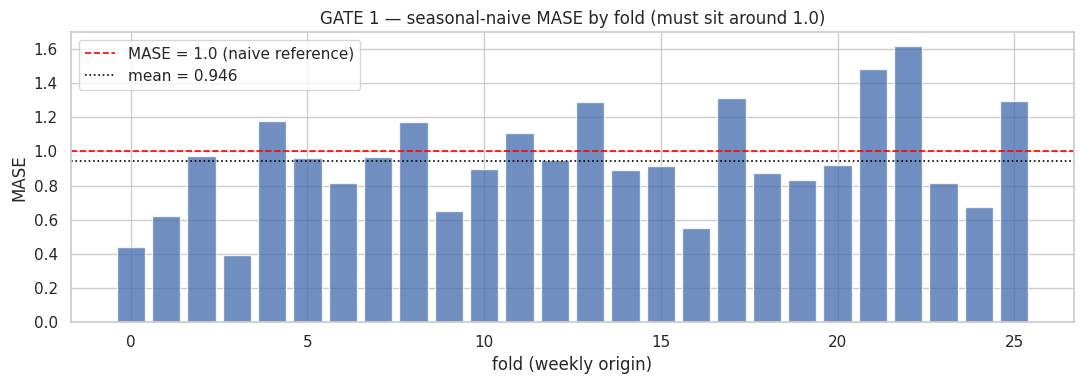

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(baseline_folds["fold"], baseline_folds["mase"], color="C0", alpha=0.8)
ax.axhline(1.0, color="red", ls="--", lw=1.2, label="MASE = 1.0 (naive reference)")
ax.axhline(m_mean, color="black", ls=":", lw=1.2, label=f"mean = {m_mean:.3f}")
ax.set_title("GATE 1 — seasonal-naive MASE by fold (must sit around 1.0)")
ax.set_xlabel("fold (weekly origin)")
ax.set_ylabel("MASE")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "model_00_baseline_sanity.png")
plt.show()


## 6 · GATE 2 — Cross-check against `utilsforecast.losses.mase`

Per the Stage 1 decision, the headline scoring is hand-rolled (no Nixtla in the metric path). To prove the implementation is right, we reconcile it against Nixtla's `utilsforecast` reference on a representative fold, then confirm the agreement holds across **all** folds.


In [7]:
from utilsforecast.losses import mase as uf_mase

def uf_mase_one_fold(fold_idx: int) -> float:
    cutoff, ts, te = cv.splits(len(y))[fold_idx]
    y_tr, y_te = y.iloc[:cutoff], y.iloc[ts:te]
    y_hat = SeasonalNaive(m=cv.m).fit(y_tr).predict(cv.horizon)
    train_df = pd.DataFrame({"unique_id": "bar", "ds": y_tr.index, "y": y_tr.values})
    eval_df = pd.DataFrame({"unique_id": "bar", "ds": y_te.index,
                            "y": y_te.values, "SeasonalNaive": y_hat})
    return float(uf_mase(eval_df, models=["SeasonalNaive"],
                         seasonality=cv.m, train_df=train_df)["SeasonalNaive"].iloc[0])

fold_idx = 13
hand = baseline_folds.loc[baseline_folds["fold"] == fold_idx, "mase"].iloc[0]
ref = uf_mase_one_fold(fold_idx)
print(f"Fold {fold_idx}:  hand-rolled = {hand:.10f}")
print(f"            utilsforecast = {ref:.10f}")
print(f"            |difference|  = {abs(hand - ref):.2e}")

max_diff = max(
    abs(baseline_folds.loc[baseline_folds['fold'] == k, 'mase'].iloc[0] - uf_mase_one_fold(k))
    for k in baseline_folds["fold"]
)
print(f"\nAcross all {len(baseline_folds)} folds: max |difference| = {max_diff:.2e}")
print(f"GATE 2: {'PASS — matches utilsforecast to fp tolerance' if max_diff < 1e-9 else 'FAIL'}")
assert max_diff < 1e-9


Fold 13:  hand-rolled = 1.2868446054
            utilsforecast = 1.2868446054
            |difference|  = 0.00e+00

Across all 26 folds: max |difference| = 3.33e-16
GATE 2: PASS — matches utilsforecast to fp tolerance


## 7 · Persist the baseline CV results

In [8]:
baseline_folds.to_csv(RESULTS / "cv_baseline_per_fold.csv", index=False)
baseline_summary.to_csv(RESULTS / "cv_baseline_summary.csv", index=False)
print("wrote results/cv_baseline_per_fold.csv")
print("wrote results/cv_baseline_summary.csv")


wrote results/cv_baseline_per_fold.csv
wrote results/cv_baseline_summary.csv


## 8 · Part A checkpoint

Both correctness gates pass:

- **Gate 1 (sanity):** seasonal-naive MASE under CV ≈ 1.0 — the scaling is right.
- **Gate 2 (cross-check):** hand-rolled MASE matches `utilsforecast.losses.mase` to floating-point tolerance across all folds.

The harness, the metric and the baseline are trustworthy. **Part B** adds SARIMA / SARIMAX (starting from the airline model the ACF/PACF indicated), Prophet, and a deliberately-modest LSTM — each through *this same* CV configuration, each scored with *this same* MASE — then assembles the comparison table and the forecast-vs-actual plot.
